## IMPORTS

In [45]:
from pathlib import Path
import numpy as np
import pandas as pd
import random
import copy

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

## GLOBAL PARAMS

In [46]:
EPOCHS = 100
PACIENCIA = 20
LEARNING_RATE = 0.0003
DECAY = 0.001
USAR_ABSOLUTO = False
K_VECINOS = 20
HIDDEN_DIM = 16
DROPOUT = 0.45

print(f"USAR_ABSOLUTO usado: {USAR_ABSOLUTO}")
print(f"K_VECINOS usado: {K_VECINOS}")
print(f"PACIENCIA usada: {PACIENCIA}")
print(f"LEARNING_RATE usado: {LEARNING_RATE}")
print(f"DECAY usado: {DECAY}")
print(f"HIDDEN_DIM usado: {HIDDEN_DIM}")
print(f"DROPOUT usado: {DROPOUT}")

USAR_ABSOLUTO usado: False
K_VECINOS usado: 20
PACIENCIA usada: 20
LEARNING_RATE usado: 0.0003
DECAY usado: 0.001
HIDDEN_DIM usado: 16
DROPOUT usado: 0.45


## EXTRA. FIJAR SEMILLA PARA REPRODUCIBILIDAD

In [47]:
SEMILLA = 168

np.random.seed(SEMILLA)
random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEMILLA)

## 1. RUTAS DEL DATASET

Los grafos están en:
- parkinson_control/
- parkinson_patient/

In [48]:
# Los grafos están en:
# parkinson_control/
# parkinson_patient/
RAIZ_DATOS = Path("./z")

CARPETA_CONTROL = RAIZ_DATOS / "parkinson_control" / "graphs"
CARPETA_PATIENT = RAIZ_DATOS / "parkinson_patient" / "graphs"

## 2. FUNCION PARA CARGAR LA MATRIZ .NPZ

Carga una matriz de conectividad desde un archivo .npz.

Intenta buscar claves habituales como:
- matriz
- connectivity
- conn
- arr_0

Si no encuentra ninguna de esas, usa la primera matriz 2D que vea dentro del archivo.

In [49]:
def cargar_matriz_desde_npz(ruta_npz: Path) -> np.ndarray:
    contenido = np.load(ruta_npz, allow_pickle=True)

    claves_preferidas = ["matriz", "connectivity", "conn", "fc", "arr_0"]
    matriz = None

    for clave in claves_preferidas:
        if clave in contenido.files and contenido[clave].ndim == 2:
            matriz = contenido[clave]
            break

    if matriz is None:
        for clave in contenido.files:
            if contenido[clave].ndim == 2:
                matriz = contenido[clave]
                break

    if matriz is None:
        raise ValueError(f"No se encontró ninguna matriz 2D válida en {ruta_npz}")

    return np.asarray(matriz, dtype=np.float32)

## 3. RECORRER LAS CARPETAS Y CREAR UNA TABLA DE MUESTRAS

Recorre los sujetos control y patient.
Para cada sujeto busca su connectivity_matrix_fmri.npz.
Control es sano y patient es "enfermo" (en nuestro caso, con Parkinson).

Devuelve un DataFrame con:
- subject_id
- label
- clase
- ruta_npz


In [50]:
def crear_tabla_muestras() -> pd.DataFrame:
    filas = []

    # Controles -> etiqueta 0
    for carpeta_sujeto in sorted(CARPETA_CONTROL.glob("sub-*")):
        ruta_npz = carpeta_sujeto / "connectivity_matrix_fmri.npz"

        if ruta_npz.exists():
            filas.append({
                "subject_id": carpeta_sujeto.name,
                "label": 0,
                "clase": "control",
                "ruta_npz": str(ruta_npz)
            })

    # Pacientes -> etiqueta 1
    for carpeta_sujeto in sorted(CARPETA_PATIENT.glob("sub-*")):
        ruta_npz = carpeta_sujeto / "connectivity_matrix_fmri.npz"

        if ruta_npz.exists():
            filas.append({
                "subject_id": carpeta_sujeto.name,
                "label": 1,
                "clase": "patient",
                "ruta_npz": str(ruta_npz)
            })

    tabla = pd.DataFrame(filas)

    if len(tabla) == 0:
        raise ValueError("No se ha encontrado ningún archivo connectivity_matrix_fmri.npz")

    return tabla

## 4. PROBAR QUE TODO ESTA BIEN

In [10]:
tabla_muestras = crear_tabla_muestras()

print("Número total de muestras:", len(tabla_muestras))
print()
print("Distribución por clase:")
print(tabla_muestras["clase"].value_counts())
print()
print("Primeras filas:")
print(tabla_muestras.head())

Número total de muestras: 225

Distribución por clase:
clase
patient    146
control     79
Name: count, dtype: int64

Primeras filas:
          subject_id  label    clase  \
0  sub-control032014      0  control   
1  sub-control032015      0  control   
2  sub-control032016      0  control   
3  sub-control032017      0  control   
4  sub-control032018      0  control   

                                            ruta_npz  
0  z\parkinson_control\graphs\sub-control032014\c...  
1  z\parkinson_control\graphs\sub-control032015\c...  
2  z\parkinson_control\graphs\sub-control032016\c...  
3  z\parkinson_control\graphs\sub-control032017\c...  
4  z\parkinson_control\graphs\sub-control032018\c...  


## 5. COMPROBAR LA FORMA DE LAS MATRICES

In [52]:
formas = []

for ruta in tabla_muestras["ruta_npz"]:
    matriz = cargar_matriz_desde_npz(Path(ruta))
    formas.append(matriz.shape)

formas_unicas = sorted(set(formas))

print()
print("Formas distintas encontradas en las matrices:")
print(formas_unicas)

if len(formas_unicas) == 1:
    print("PERFECTOOO: todas las matrices tienen la misma forma.")
else:
    print("OJOOOO: hay matrices con formas distintas. Así no podremos entrenar todavía.")

# Mostramos cuántas muestras hay de cada forma:
print("Número de muestras por forma de matriz:")
for forma in formas_unicas:
    count = formas.count(forma)
    print(f"{forma}: {count} muestras")

# Mostrar, de las 116, 116 cuántas son patient y cuántas son control:
print("\nDistribución por clase para cada forma de matriz:")
for forma in formas_unicas:
    print(f"\nPara la forma {forma}:")
    muestras_forma = [tabla_muestras.iloc[i] for i in range(len(tabla_muestras)) if cargar_matriz_desde_npz(Path(tabla_muestras.iloc[i]["ruta_npz"])).shape == forma]
    count_patient = sum(1 for muestra in muestras_forma if muestra["clase"] == "patient")
    count_control = sum(1 for muestra in muestras_forma if muestra["clase"] == "control")
    print(f"  - Patient: {count_patient}")
    print(f"  - Control: {count_control}")


Formas distintas encontradas en las matrices:
[(2, 2), (83, 83), (85, 85), (86, 86), (87, 87), (95, 95), (97, 97), (99, 99), (101, 101), (103, 103), (106, 106), (107, 107), (108, 108), (109, 109), (110, 110), (111, 111), (112, 112), (113, 113), (114, 114), (115, 115), (116, 116)]
OJOOOO: hay matrices con formas distintas. Así no podremos entrenar todavía.
Número de muestras por forma de matriz:
(2, 2): 1 muestras
(83, 83): 1 muestras
(85, 85): 1 muestras
(86, 86): 2 muestras
(87, 87): 1 muestras
(95, 95): 2 muestras
(97, 97): 1 muestras
(99, 99): 2 muestras
(101, 101): 1 muestras
(103, 103): 1 muestras
(106, 106): 1 muestras
(107, 107): 1 muestras
(108, 108): 2 muestras
(109, 109): 2 muestras
(110, 110): 1 muestras
(111, 111): 2 muestras
(112, 112): 9 muestras
(113, 113): 9 muestras
(114, 114): 1 muestras
(115, 115): 9 muestras
(116, 116): 175 muestras

Distribución por clase para cada forma de matriz:

Para la forma (2, 2):
  - Patient: 1
  - Control: 0

Para la forma (83, 83):
  - P

## 6. FILTRAR SOLO LAS MATRICES 116x116

Se queda solo con los sujetos cuya matriz de conectividad tiene exactamente la forma indicada en tamano_objetivo.

In [12]:
def filtrar_matrices_tamano_fijo(tabla_muestras: pd.DataFrame, tamano_objetivo=(116, 116)) -> pd.DataFrame:
    filas_validas = []

    for _, fila in tabla_muestras.iterrows():
        ruta_npz = Path(fila["ruta_npz"])
        matriz = cargar_matriz_desde_npz(ruta_npz)

        if matriz.shape == tamano_objetivo:
            nueva_fila = fila.to_dict()
            nueva_fila["forma_matriz"] = matriz.shape
            filas_validas.append(nueva_fila)

    tabla_filtrada = pd.DataFrame(filas_validas)

    if len(tabla_filtrada) == 0:
        raise ValueError(f"No se encontraron matrices con forma {tamano_objetivo}")

    return tabla_filtrada

## 7. DIVIDIR EN TRAIN / VAL / TEST

Hacemos una división por PARETO:
- 80% train+val
- 20% test

Y después:
- 80% de train+val para train
- 20% de train+val para val

Resultado final aproximado:
- 64% train
- 16% val
- 20% test

In [13]:
def dividir_dataset(tabla_filtrada: pd.DataFrame, semilla=42):
    tabla_train_val, tabla_test = train_test_split(
        tabla_filtrada,
        test_size=0.20,
        random_state=semilla,
        stratify=tabla_filtrada["label"]
    )

    tabla_train, tabla_val = train_test_split(
        tabla_train_val,
        test_size=0.20,
        random_state=semilla,
        stratify=tabla_train_val["label"]
    )

    # Reiniciamos índices para dejarlo limpio
    tabla_train = tabla_train.reset_index(drop=True)
    tabla_val = tabla_val.reset_index(drop=True)
    tabla_test = tabla_test.reset_index(drop=True)

    return tabla_train, tabla_val, tabla_test

## 8. GUARDAR EL SPLIT EN UNA TABLA GENERAL

Une las tres tablas y añade una columna 'split'
para saber qué sujeto pertenece a cada partición.

In [14]:
def crear_tabla_splits(tabla_train, tabla_val, tabla_test):
    tabla_train = tabla_train.copy()
    tabla_val = tabla_val.copy()
    tabla_test = tabla_test.copy()

    tabla_train["split"] = "train"
    tabla_val["split"] = "val"
    tabla_test["split"] = "test"

    tabla_splits = pd.concat([tabla_train, tabla_val, tabla_test], ignore_index=True)
    return tabla_splits

## 9. EJECUTAR EL FILTRADO Y LA DIVISION

In [15]:
tabla_116 = filtrar_matrices_tamano_fijo(tabla_muestras, tamano_objetivo=(116, 116))

print("Número de muestras con matriz 116x116:", len(tabla_116))
print()
print("Distribución por clase en las 116x116:")
print(tabla_116["clase"].value_counts())

tabla_train, tabla_val, tabla_test = dividir_dataset(tabla_116, semilla=SEMILLA)

print()
print("Tamaños de los splits:")
print("Train:", len(tabla_train))
print("Val  :", len(tabla_val))
print("Test :", len(tabla_test))

print()
print("Distribución por clase en TRAIN:")
print(tabla_train["clase"].value_counts())

print()
print("Distribución por clase en VAL:")
print(tabla_val["clase"].value_counts())

print()
print("Distribución por clase en TEST:")
print(tabla_test["clase"].value_counts())

tabla_splits = crear_tabla_splits(tabla_train, tabla_val, tabla_test)

print()
print("Primeras filas de la tabla final de splits:")
print(tabla_splits.head())

Número de muestras con matriz 116x116: 175

Distribución por clase en las 116x116:
clase
patient    115
control     60
Name: count, dtype: int64

Tamaños de los splits:
Train: 112
Val  : 28
Test : 35

Distribución por clase en TRAIN:
clase
patient    74
control    38
Name: count, dtype: int64

Distribución por clase en VAL:
clase
patient    18
control    10
Name: count, dtype: int64

Distribución por clase en TEST:
clase
patient    23
control    12
Name: count, dtype: int64

Primeras filas de la tabla final de splits:
               subject_id  label    clase  \
0  sub-patient032041 copy      1  patient   
1                sub-0264      1  patient   
2              sub-MJF013      1  patient   
3               sub-HK037      0  control   
4                sub-0252      1  patient   

                                            ruta_npz forma_matriz  split  
0  z\parkinson_patient\graphs\sub-patient032041 c...   (116, 116)  train  
1  z\parkinson_patient\graphs\sub-0264\connectivi...   

## 10. GUARDAR LA TABLA A CSV

In [16]:
tabla_splits.to_csv("splits_parkinson_116x116.csv", index=False)
print()
print("Tabla de splits guardada en: splits_parkinson_116x116.csv")


Tabla de splits guardada en: splits_parkinson_116x116.csv


## 11. LIMPIAR LA MATRIZ DE CONECTIVIDAD

Limpia la matriz para dejarla lista para construir el grafo.

- elimina NaN e infinitos (los que estaban por debajo del threshold cuando he hecho la transformación en EEGraph)
- fuerza simetría
- pone la diagonal a 0s (ya debería estar así de EEGraph, pero por si acaso)
- opcionalmente usa valor absoluto
- si no usamos absoluto, eliminamos valores negativos

In [17]:
def limpiar_matriz(matriz: np.ndarray, usar_absoluto=False) -> np.ndarray:
    matriz = np.nan_to_num(matriz, nan=0.0, posinf=0.0, neginf=0.0)

    # Forzamos simetría
    matriz = (matriz + matriz.T) / 2.0

    # Quitamos autoconexiones
    np.fill_diagonal(matriz, 0.0)

    if usar_absoluto:
        matriz = np.abs(matriz)
    else:
        matriz[matriz < 0] = 0.0

    return matriz.astype(np.float32)

## 12. CREAR FEATURES DE NODO

Construye features para cada nodo a partir de la matriz de conectividad.

Usamos la fila completa de conectividad de cada ROI, para no perder tanta información.

Salida: matriz de shape (num_nodos, num_nodos) En una matriz 116x116, cada nodo tendrá 116 features.

In [18]:
def construir_features_nodo(matriz: np.ndarray) -> np.ndarray:
    features = matriz.astype(np.float32)
    return features

## 13. CONSTRUIR LAS ARISTAS DEL GRAFO

Para cada nodo, conserva solo las k conexiones más fuertes.
Después simetriza la conectividad para obtener un grafo no dirigido.

Devuelve:
- edge_index: tensor con forma [2, num_aristas]
- edge_weight: tensor con los pesos de las aristas

In [19]:
def construir_aristas_desde_matriz(matriz: np.ndarray, k_vecinos=10):
    num_nodos = matriz.shape[0]
    k_vecinos = min(k_vecinos, num_nodos - 1)

    mascara = np.zeros_like(matriz, dtype=bool)

    for i in range(num_nodos):
        fila = matriz[i].copy()
        fila[i] = -np.inf

        indices_topk = np.argpartition(fila, -k_vecinos)[-k_vecinos:]

        # Nos quedamos solo con conexiones positivas
        indices_topk = indices_topk[fila[indices_topk] > 0]

        mascara[i, indices_topk] = True

    # Simetrizamos para que el grafo sea no dirigido
    mascara = np.logical_or(mascara, mascara.T)

    origen, destino = np.where(mascara)
    pesos = matriz[origen, destino].astype(np.float32)

    edge_index = torch.tensor(
        np.vstack([origen, destino]),
        dtype=torch.long
    )
    edge_weight = torch.tensor(pesos, dtype=torch.float32)

    return edge_index, edge_weight

## 14. CONVERTIR UNA MUESTRA EN UN OBJETO DATA DE PYG

Convierte una fila de la tabla (un sujeto) en un objeto Data de PyTorch Geometric.

In [20]:
def crear_grafo_desde_fila(fila_tabla, usar_absoluto=False, k_vecinos=10) -> Data:
    ruta_npz = Path(fila_tabla["ruta_npz"])
    label = int(fila_tabla["label"])
    subject_id = fila_tabla["subject_id"]

    matriz = cargar_matriz_desde_npz(ruta_npz)
    matriz = limpiar_matriz(matriz, usar_absoluto=usar_absoluto)

    x = construir_features_nodo(matriz)
    edge_index, edge_weight = construir_aristas_desde_matriz(matriz, k_vecinos=k_vecinos)

    data = Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=edge_index,
        edge_weight=edge_weight,
        y=torch.tensor([label], dtype=torch.float32)
    )

    # Guardamos algunos metadatos útiles
    data.subject_id = subject_id
    data.ruta_npz = str(ruta_npz)
    data.num_nodos_original = matriz.shape[0]

    return data

## 15. CONVERTIR TRAIN / VAL / TEST A LISTAS DE GRAFOS

Convierte una tabla de sujetos en una lista de objetos Data.

In [21]:
def convertir_tabla_a_lista_grafos(tabla: pd.DataFrame, usar_absoluto=False, k_vecinos=10):
    lista_grafos = []

    for _, fila in tabla.iterrows():
        grafo = crear_grafo_desde_fila(
            fila,
            usar_absoluto=usar_absoluto,
            k_vecinos=k_vecinos
        )
        lista_grafos.append(grafo)

    return lista_grafos

## 15B. NORMALIZAR FEATURES DE NODO USANDO SOLO TRAIN

Normaliza las features de nodo usando SOLO las estadísticas de train. Esto ayuda mucho si hay diferencias de escala entre sujetos o datasets.

In [22]:
def normalizar_features_grafos(train_graphs, val_graphs, test_graphs):
    x_train = torch.cat([g.x for g in train_graphs], dim=0)

    media = x_train.mean(dim=0, keepdim=True)
    desviacion = x_train.std(dim=0, keepdim=True)

    # Evitamos divisiones por 0
    desviacion = torch.clamp(desviacion, min=1e-6)

    for lista in [train_graphs, val_graphs, test_graphs]:
        for g in lista:
            g.x = (g.x - media) / desviacion

    return train_graphs, val_graphs, test_graphs

## 16. CREAR LOS GRAFOS PARA CADA SPLIT

In [23]:
train_graphs = convertir_tabla_a_lista_grafos(
    tabla_train,
    usar_absoluto=USAR_ABSOLUTO,
    k_vecinos=K_VECINOS
)

val_graphs = convertir_tabla_a_lista_grafos(
    tabla_val,
    usar_absoluto=USAR_ABSOLUTO,
    k_vecinos=K_VECINOS
)

test_graphs = convertir_tabla_a_lista_grafos(
    tabla_test,
    usar_absoluto=USAR_ABSOLUTO,
    k_vecinos=K_VECINOS
)

# Normalizamos features usando solo train
train_graphs, val_graphs, test_graphs = normalizar_features_grafos(
    train_graphs,
    val_graphs,
    test_graphs
)

print("Número de grafos en train:", len(train_graphs))
print("Número de grafos en val :", len(val_graphs))
print("Número de grafos en test :", len(test_graphs))
print()

print("Ejemplo de un grafo:")
print(train_graphs[0])
print()

print("Shape de las features de nodo del primer grafo:", train_graphs[0].x.shape)
print("Shape de edge_index del primer grafo:", train_graphs[0].edge_index.shape)
print("Shape de edge_weight del primer grafo:", train_graphs[0].edge_weight.shape)
print("Etiqueta del primer grafo:", train_graphs[0].y.item())
print("Subject ID del primer grafo:", train_graphs[0].subject_id)

Número de grafos en train: 112
Número de grafos en val : 28
Número de grafos en test : 35

Ejemplo de un grafo:
Data(x=[116, 116], edge_index=[2, 460], y=[1], edge_weight=[460], subject_id='sub-patient032041 copy', ruta_npz='z\parkinson_patient\graphs\sub-patient032041 copy\connectivity_matrix_fmri.npz', num_nodos_original=116)

Shape de las features de nodo del primer grafo: torch.Size([116, 116])
Shape de edge_index del primer grafo: torch.Size([2, 460])
Shape de edge_weight del primer grafo: torch.Size([460])
Etiqueta del primer grafo: 1.0
Subject ID del primer grafo: sub-patient032041 copy


## 17. CREAR LOS DATALOADERS

In [24]:
BATCH_SIZE = 8

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

print("Número de batches en train:", len(train_loader))
print("Número de batches en val  :", len(val_loader))
print("Número de batches en test :", len(test_loader))

Número de batches en train: 14
Número de batches en val  : 4
Número de batches en test : 5


## 18. DEFINIR LA RED GNN

Red de grafos sencilla para clasificación binaria.

Estructura:
- 3 capas GCNConv
- ReLU y Dropout entre capas.
- pooling global para obtener una representación por grafo
- 2 capas lineales finales

In [25]:
class RedGCNBinaria(nn.Module):
    def __init__(self, num_features_entrada, hidden_dim=32, dropout=0.5):
        super().__init__()

        self.conv1 = GCNConv(num_features_entrada, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim // 2)

        self.dropout = nn.Dropout(dropout)

        # conv3 saca hidden_dim//2
        # al concatenar mean + max tenemos el doble:
        # (hidden_dim//2) + (hidden_dim//2) = hidden_dim
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        edge_weight = data.edge_weight
        batch = data.batch

        # Capa 1
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = self.dropout(x)

        # Capa 2
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = self.dropout(x)

        # Capa 3
        x = self.conv3(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)

        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)

        # Clasificador final
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        logits = self.fc2(x).squeeze(1)
        return logits

## 19. CREAR EL MODELO

In [26]:
num_features_entrada = train_graphs[0].x.shape[1]

modelo = RedGCNBinaria(
    num_features_entrada=num_features_entrada,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
)

print(modelo)

RedGCNBinaria(
  (conv1): GCNConv(116, 16)
  (conv2): GCNConv(16, 16)
  (conv3): GCNConv(16, 8)
  (dropout): Dropout(p=0.45, inplace=False)
  (fc1): Linear(in_features=16, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


### 20. PROBAR UN BATCH

Esto simplemente es una ejecución previa de prueba

In [27]:
batch_ejemplo = next(iter(train_loader))
salida = modelo(batch_ejemplo)

print()
print("Shape del batch de entrada (x):", batch_ejemplo.x.shape)
print("Shape de batch_ejemplo.batch:", batch_ejemplo.batch.shape)
print("Shape de la salida del modelo:", salida.shape)
print("Salida del modelo:")
print(salida)


Shape del batch de entrada (x): torch.Size([928, 116])
Shape de batch_ejemplo.batch: torch.Size([928])
Shape de la salida del modelo: torch.Size([8])
Salida del modelo:
tensor([ 0.4643, -0.1476,  0.4255,  0.7604,  0.1366,  0.2594,  0.9952,  0.3176],
       grad_fn=<SqueezeBackward1>)


## 21. CONFIGURAR DISPOSITIVO, LOSS Y OPTIMIZADOR

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo usado:", device)

modelo = modelo.to(device)

# Calculamos el peso de la clase positiva (patient = 1)
etiquetas_train = np.array([int(g.y.item()) for g in train_graphs])
num_positivos = (etiquetas_train == 1).sum()
num_negativos = (etiquetas_train == 0).sum()

peso_clase_positiva = num_negativos / max(num_positivos, 1)
peso_clase_positiva = torch.tensor([peso_clase_positiva], dtype=torch.float32).to(device)

criterio = nn.BCEWithLogitsLoss(pos_weight=peso_clase_positiva)

optimizer = torch.optim.Adam(
    modelo.parameters(),
    lr=LEARNING_RATE,
    weight_decay=DECAY
)

print("Peso clase positiva:", peso_clase_positiva.item())

Dispositivo usado: cpu
Peso clase positiva: 0.5135135054588318


## 22. FUNCION PARA ENTRENAR UNA EPOCA

Entrena el modelo durante una época completa.

Devuelve:
- loss media
- accuracy
- precision
- recall
- f1
- auc

In [29]:
def entrenar_una_epoca(modelo, loader, optimizer, criterio, device):
    modelo.train()

    perdidas = []
    y_reales = []
    y_probs = []

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        logits = modelo(batch)
        y = batch.y.view(-1)

        loss = criterio(logits, y)
        loss.backward()
        optimizer.step()

        perdidas.append(loss.item())

        probs = torch.sigmoid(logits)

        y_reales.extend(y.detach().cpu().numpy())
        y_probs.extend(probs.detach().cpu().numpy())

    y_reales = np.array(y_reales)
    y_probs = np.array(y_probs)
    y_predichas = (y_probs >= 0.5).astype(int)

    metricas = {
        "loss": float(np.mean(perdidas)),
        "accuracy": accuracy_score(y_reales, y_predichas),
        "precision": precision_score(y_reales, y_predichas, zero_division=0),
        "recall": recall_score(y_reales, y_predichas, zero_division=0),
        "f1": f1_score(y_reales, y_predichas, zero_division=0),
        "auc": roc_auc_score(y_reales, y_probs) if len(np.unique(y_reales)) > 1 else np.nan
    }

    return metricas

## 23. FUNCION PARA EVALUAR

Evalúa el modelo sin actualizar pesos.

Devuelve las mismas métricas que en entrenamiento.

In [30]:
@torch.no_grad()
def evaluar_modelo(modelo, loader, criterio, device):
    modelo.eval()

    perdidas = []
    y_reales = []
    y_probs = []

    for batch in loader:
        batch = batch.to(device)

        logits = modelo(batch)
        y = batch.y.view(-1)

        loss = criterio(logits, y)
        perdidas.append(loss.item())

        probs = torch.sigmoid(logits)

        y_reales.extend(y.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

    y_reales = np.array(y_reales)
    y_probs = np.array(y_probs)
    y_predichas = (y_probs >= 0.5).astype(int)

    metricas = {
        "loss": float(np.mean(perdidas)),
        "accuracy": accuracy_score(y_reales, y_predichas),
        "precision": precision_score(y_reales, y_predichas, zero_division=0),
        "recall": recall_score(y_reales, y_predichas, zero_division=0),
        "f1": f1_score(y_reales, y_predichas, zero_division=0),
        "auc": roc_auc_score(y_reales, y_probs) if len(np.unique(y_reales)) > 1 else np.nan,
        "y_reales": y_reales,
        "y_probs": y_probs,
        "y_predichas": y_predichas
    }

    return metricas

## 24. HISTORIAL DE ENTRENAMIENTO

In [31]:
historial = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": [],
    "train_auc": [],
    "val_auc": []
}

## 25. VARIABLES PARA EARLY STOPPING

In [32]:
MIN_DELTA_ES = 1e-4
UMBRAL_GAP_F1 = 0.10

mejor_val_f1 = float("-inf")
mejor_val_auc = float("-inf")
mejor_estado_modelo = None
epocas_sin_mejora = 0

RUTA_MEJOR_MODELO = "mejor_modelo_gcnn_parkinson.pth"

# 26. BUCLE COMPLETO DE ENTRENAMIENTO

In [33]:
for epoca in range(1, EPOCHS + 1):
    metricas_train = entrenar_una_epoca(modelo, train_loader, optimizer, criterio, device)
    metricas_val = evaluar_modelo(modelo, val_loader, criterio, device)

    # Guardamos historial
    historial["train_loss"].append(metricas_train["loss"])
    historial["val_loss"].append(metricas_val["loss"])

    historial["train_accuracy"].append(metricas_train["accuracy"])
    historial["val_accuracy"].append(metricas_val["accuracy"])

    historial["train_precision"].append(metricas_train["precision"])
    historial["val_precision"].append(metricas_val["precision"])

    historial["train_recall"].append(metricas_train["recall"])
    historial["val_recall"].append(metricas_val["recall"])

    historial["train_f1"].append(metricas_train["f1"])
    historial["val_f1"].append(metricas_val["f1"])

    historial["train_auc"].append(metricas_train["auc"])
    historial["val_auc"].append(metricas_val["auc"])

    print(
        f"Época {epoca:03d} | "
        f"Train Loss: {metricas_train['loss']:.4f} | "
        f"Val Loss: {metricas_val['loss']:.4f} | "
        f"Train Acc: {metricas_train['accuracy']:.4f} | "
        f"Val Acc: {metricas_val['accuracy']:.4f} | "
        f"Train F1: {metricas_train['f1']:.4f} | "
        f"Val F1: {metricas_val['f1']:.4f}"
    )

    gap_f1_train_val = metricas_train["f1"] - metricas_val["f1"]

    if gap_f1_train_val > UMBRAL_GAP_F1:
        print(
            f"Aviso overfitting -> gap F1 train-val: {gap_f1_train_val:.4f} "
            f"(umbral {UMBRAL_GAP_F1:.2f})"
        )

    # Comprobamos mejora en validación usando F1 (desempate por AUC)
    val_f1_actual = metricas_val["f1"]
    val_auc_actual = metricas_val["auc"]
    if np.isnan(val_auc_actual):
        val_auc_actual = float("-inf")

    mejora_f1 = val_f1_actual > (mejor_val_f1 + MIN_DELTA_ES)
    empate_f1 = abs(val_f1_actual - mejor_val_f1) <= MIN_DELTA_ES
    mejora_auc_en_empate = val_auc_actual > (mejor_val_auc + MIN_DELTA_ES)

    if mejora_f1 or (empate_f1 and mejora_auc_en_empate):
        mejor_val_f1 = val_f1_actual
        mejor_val_auc = val_auc_actual
        mejor_estado_modelo = copy.deepcopy(modelo.state_dict())
        torch.save(mejor_estado_modelo, RUTA_MEJOR_MODELO)
        epocas_sin_mejora = 0
    else:
        epocas_sin_mejora += 1

    # Early stopping
    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nEarly stopping activado en la época {epoca}.")
        break

Época 001 | Train Loss: 0.4876 | Val Loss: 0.4921 | Train Acc: 0.5982 | Val Acc: 0.6429 | Train F1: 0.7337 | Val F1: 0.7826
Época 002 | Train Loss: 0.4914 | Val Loss: 0.4902 | Train Acc: 0.5804 | Val Acc: 0.6429 | Train F1: 0.7186 | Val F1: 0.7826
Época 003 | Train Loss: 0.4649 | Val Loss: 0.4888 | Train Acc: 0.6518 | Val Acc: 0.6429 | Train F1: 0.7719 | Val F1: 0.7826
Época 004 | Train Loss: 0.4924 | Val Loss: 0.4881 | Train Acc: 0.5714 | Val Acc: 0.6429 | Train F1: 0.7108 | Val F1: 0.7826
Época 005 | Train Loss: 0.4631 | Val Loss: 0.4869 | Train Acc: 0.6429 | Val Acc: 0.6429 | Train F1: 0.7531 | Val F1: 0.7826
Época 006 | Train Loss: 0.4775 | Val Loss: 0.4850 | Train Acc: 0.5625 | Val Acc: 0.6429 | Train F1: 0.7101 | Val F1: 0.7826
Época 007 | Train Loss: 0.4779 | Val Loss: 0.4827 | Train Acc: 0.5179 | Val Acc: 0.6429 | Train F1: 0.6447 | Val F1: 0.7826
Época 008 | Train Loss: 0.4754 | Val Loss: 0.4809 | Train Acc: 0.5536 | Val Acc: 0.6429 | Train F1: 0.6914 | Val F1: 0.7826
Época 00

## 27. CARGAR EL MEJOR MODELO AL FINAL

In [34]:
modelo.load_state_dict(torch.load(RUTA_MEJOR_MODELO, map_location=device))
print("\nMejor modelo cargado desde:", RUTA_MEJOR_MODELO)
print("Mejor val_f1 alcanzado:", mejor_val_f1)
print("Mejor val_auc asociado:", mejor_val_auc)


Mejor modelo cargado desde: mejor_modelo_gcnn_parkinson.pth
Mejor val_f1 alcanzado: 0.9142857142857143
Mejor val_auc asociado: 0.8888888888888888


# 28. EVALUACIÓN FINAL EN TEST

## EXTRA. RESUMEN FINAL DE PRECISIÓN EN TRAIN / EVAL / TEST

In [35]:
metricas_train_final = evaluar_modelo(modelo, train_loader, criterio, device)
metricas_val_final = evaluar_modelo(modelo, val_loader, criterio, device)
metricas_test = evaluar_modelo(modelo, test_loader, criterio, device)

print("\n" + "=" * 60)
print("RESUMEN FINAL DE PRECISIÓN - TRAIN / EVAL / TEST")
print("=" * 60)
print(f"Precision TRAIN: {metricas_train_final['precision']:.4f}")
print(f"Precision EVAL : {metricas_val_final['precision']:.4f}")
print(f"Precision TEST : {metricas_test['precision']:.4f}")

print("\n" + "=" * 60)
print("OTRAS MÉTRICAS FINALES - TRAIN / EVAL / TEST")
print("=" * 60)
print(
    f"TRAIN -> Loss: {metricas_train_final['loss']:.4f} | "
    f"Acc: {metricas_train_final['accuracy']:.4f} | "
    f"Recall: {metricas_train_final['recall']:.4f} | "
    f"F1: {metricas_train_final['f1']:.4f} | "
    f"AUC: {metricas_train_final['auc']:.4f}"
)
print(
    f"EVAL  -> Loss: {metricas_val_final['loss']:.4f} | "
    f"Acc: {metricas_val_final['accuracy']:.4f} | "
    f"Recall: {metricas_val_final['recall']:.4f} | "
    f"F1: {metricas_val_final['f1']:.4f} | "
    f"AUC: {metricas_val_final['auc']:.4f}"
)
print(
    f"TEST  -> Loss: {metricas_test['loss']:.4f} | "
    f"Acc: {metricas_test['accuracy']:.4f} | "
    f"Recall: {metricas_test['recall']:.4f} | "
    f"F1: {metricas_test['f1']:.4f} | "
    f"AUC: {metricas_test['auc']:.4f}"
)

metricas_test = evaluar_modelo(modelo, test_loader, criterio, device)

print("\n" + "=" * 60)
print("RESULTADOS FINALES EN TEST")
print("=" * 60)

print(f"Loss     : {metricas_test['loss']:.4f}")
print(f"Accuracy : {metricas_test['accuracy']:.4f}")
print(f"Precision: {metricas_test['precision']:.4f}")
print(f"Recall   : {metricas_test['recall']:.4f}")
print(f"F1-score : {metricas_test['f1']:.4f}")
print(f"AUC      : {metricas_test['auc']:.4f}")


RESUMEN FINAL DE PRECISIÓN - TRAIN / EVAL / TEST
Precision TRAIN: 1.0000
Precision EVAL : 0.9412
Precision TEST : 0.9130

OTRAS MÉTRICAS FINALES - TRAIN / EVAL / TEST
TRAIN -> Loss: 0.0788 | Acc: 0.9643 | Recall: 0.9459 | F1: 0.9722 | AUC: 0.9968
EVAL  -> Loss: 0.7931 | Acc: 0.8929 | Recall: 0.8889 | F1: 0.9143 | AUC: 0.8889
TEST  -> Loss: 0.2492 | Acc: 0.8857 | Recall: 0.9130 | F1: 0.9130 | AUC: 0.9239

RESULTADOS FINALES EN TEST
Loss     : 0.2492
Accuracy : 0.8857
Precision: 0.9130
Recall   : 0.9130
F1-score : 0.9130
AUC      : 0.9239


## 29. MATRIZ DE CONFUSIÓN

In [36]:
cm = confusion_matrix(metricas_test["y_reales"], metricas_test["y_predichas"])

print("\nMatriz de confusión:")
print(cm)


Matriz de confusión:
[[10  2]
 [ 2 21]]


## 30. REPORTE DE CLASIFICACIÓN

In [37]:
print("\nReporte de clasificación:")
print(
    classification_report(
        metricas_test["y_reales"],
        metricas_test["y_predichas"],
        target_names=["Control", "Parkinson"],
        zero_division=0
    )
)


Reporte de clasificación:
              precision    recall  f1-score   support

     Control       0.83      0.83      0.83        12
   Parkinson       0.91      0.91      0.91        23

    accuracy                           0.89        35
   macro avg       0.87      0.87      0.87        35
weighted avg       0.89      0.89      0.89        35



## 31. GUARDAR PREDICCIONES DE TEST EN CSV

Como test_loader tiene shuffle=False, el orden coincide con tabla_test

In [38]:
tabla_resultados_test = tabla_test.copy().reset_index(drop=True)

tabla_resultados_test["y_real"] = metricas_test["y_reales"].astype(int)
tabla_resultados_test["y_prob"] = metricas_test["y_probs"]
tabla_resultados_test["y_pred"] = metricas_test["y_predichas"].astype(int)

tabla_resultados_test["prediccion_texto"] = tabla_resultados_test["y_pred"].map({
    0: "control",
    1: "patient"
})

tabla_resultados_test.to_csv("predicciones_test_gcnn.csv", index=False)

print("\nPredicciones de test guardadas en: predicciones_test_gcnn.csv")
print("\nPrimeras filas del archivo de predicciones:")
print(tabla_resultados_test.head())


Predicciones de test guardadas en: predicciones_test_gcnn.csv

Primeras filas del archivo de predicciones:
          subject_id  label    clase  \
0  sub-control032019      0  control   
1         sub-MJF039      1  patient   
2          sub-HK019      0  control   
3  sub-patient032049      1  patient   
4  sub-control032022      0  control   

                                            ruta_npz forma_matriz  y_real  \
0  z\parkinson_control\graphs\sub-control032019\c...   (116, 116)       0   
1  z\parkinson_patient\graphs\sub-MJF039\connecti...   (116, 116)       1   
2  z\parkinson_control\graphs\sub-HK019\connectiv...   (116, 116)       0   
3  z\parkinson_patient\graphs\sub-patient032049\c...   (116, 116)       1   
4  z\parkinson_control\graphs\sub-control032022\c...   (116, 116)       0   

     y_prob  y_pred prediccion_texto  
0  0.231251       0          control  
1  0.612851       1          patient  
2  0.204404       0          control  
3  0.995743       1          pat

# MOSTRAR RESULTADOS

## FUNCIÓN GENERAL PARA DIBUJAR CURVAS

In [39]:
def dibujar_curva(historial, clave_train, clave_val, titulo, ylabel, nombre_archivo):
    """
    Dibuja una curva de entrenamiento/validación y la guarda a disco.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(historial[clave_train], label=f"Train {ylabel}")
    plt.plot(historial[clave_val], label=f"Val {ylabel}")
    plt.title(titulo)
    plt.xlabel("Época")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=150)
    plt.show()

### MATRIZ DE CONFUSIÓN

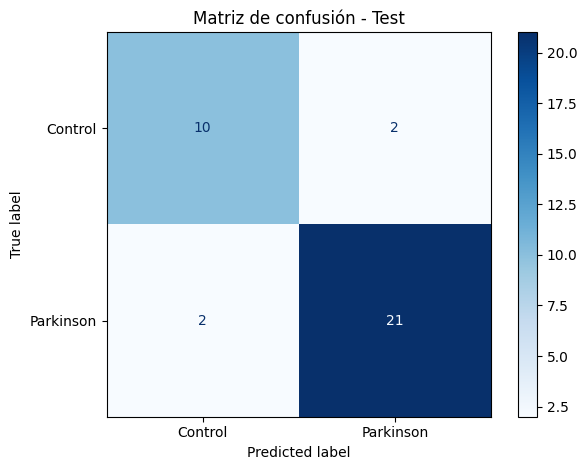

In [40]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "Parkinson"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Test")
plt.tight_layout()
plt.show()

### CURVA DE ACCURACY

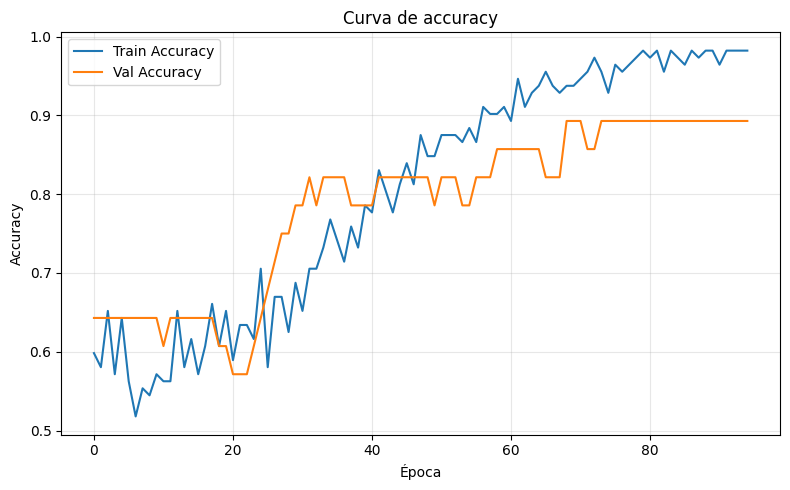

In [42]:
dibujar_curva(
    historial=historial,
    clave_train="train_accuracy",
    clave_val="val_accuracy",
    titulo="Curva de accuracy",
    ylabel="Accuracy",
    nombre_archivo="curva_accuracy_gcnn.png"
)

### CURVA DE F1-SCORE

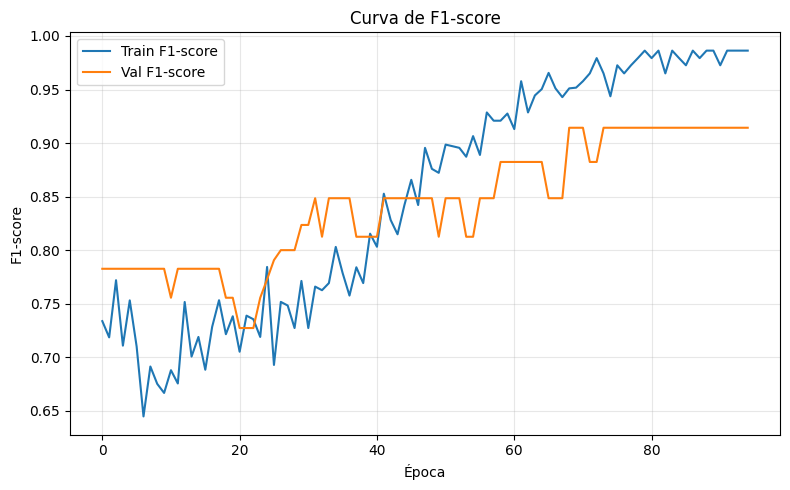

In [43]:
dibujar_curva(
    historial=historial,
    clave_train="train_f1",
    clave_val="val_f1",
    titulo="Curva de F1-score",
    ylabel="F1-score",
    nombre_archivo="curva_f1_gcnn.png"
)

### CURVA DE AUC

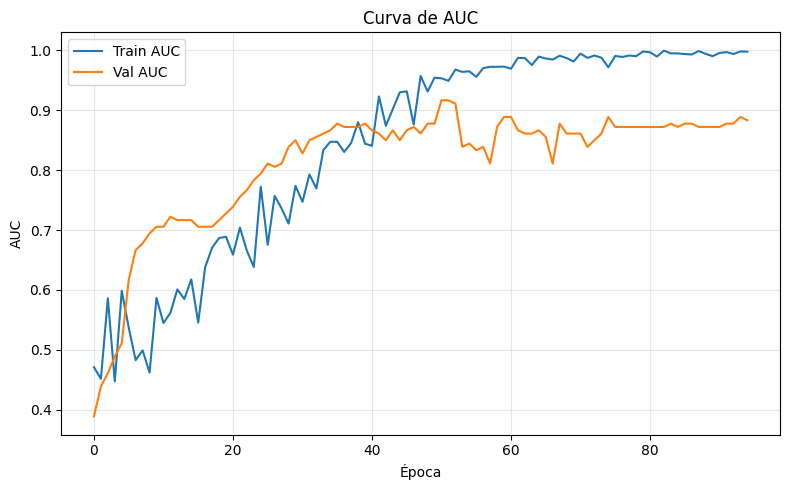

In [44]:
dibujar_curva(
    historial=historial,
    clave_train="train_auc",
    clave_val="val_auc",
    titulo="Curva de AUC",
    ylabel="AUC",
    nombre_archivo="curva_auc_gcnn.png"
)